# CNN

## The Nature Conservancy Fisheries Monitoring dataset


"Nearly half of the world depends on seafood for their main source of protein. In the Western and Central Pacific, where 60% of the world’s tuna is caught, illegal, unreported, and unregulated fishing practices are threatening marine ecosystems, global seafood supplies and local livelihoods. The Nature Conservancy is working with local, regional and global partners to preserve this fishery for the future. Currently, the Conservancy is looking to the future by using cameras to dramatically scale the monitoring of fishing activities to fill critical science and compliance monitoring data gaps. Although these electronic monitoring systems work well and are ready for wider deployment, the amount of raw data produced is cumbersome and expensive to process manually."

"The objective is to develop algorithms to automatically detect and classify species of tunas, sharks and more that fishing boats catch, which will accelerate the video review process. Faster review and more reliable data will enable countries to reallocate human capital to management and enforcement activities which will have a positive impact on conservation and our planet."

## Task 1
You are required to prepare the data from the directories that contains the data. Each subdirectory represents a label for fish type. That means we have to list all the subdirectories first. Then load the images from each of these subdirectory. Finaaly print out the dimensions to see how your data looks like.

In [1]:
import os

# Get all subdirectories of data directory "train" folder. Each subdirectory represents a label.
directories = [d for d in os.listdir("train") if os.path.isdir(os.path.join("train", d))]
directories

['ALB', 'BET', 'DOL', 'LAG', 'NoF', 'OTHER', 'SHARK', 'YFT']

In [2]:
import cv2 # computer vision package we've used before
import numpy as np

# Loop through the label subdirectories and collect the data in two lists, 
# one list for labels themselves and one list for the images inside those label folders.
labels = []
images = []

category = 0 # this is tp label the data baased on the subdirectory number
for d in directories:
    label_dir = os.path.join("train", d)
    # get all the image files (all .jpg) in each subdirectory
    file_names = [os.path.join(label_dir, f) for f in os.listdir(label_dir) if f.endswith(".jpg")]
    
    # counter = 0 # I put this counter in order to work on a part of the images coz it takes a while
    for f in file_names:
        img = cv2.imread(f)
        imresize = cv2.resize(img, (200, 125))
        images.append(imresize)
        labels.append(category)
        #if counter > 50:  # remove this to use full dataset
            #break
        #counter += 1
            
    category += 1 # we increment when finishing the subdirectory before moving to another subdirectory for another fish type
    


In [3]:
images = np.array(images)
images.shape

(3777, 125, 200, 3)

In [4]:
labels = np.array(labels)
labels.shape

(3777,)

## Task 2 
You are required to split the data into train and test sets where the test set is 20%

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=1234)

In [6]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(3021, 125, 200, 3)
(3021,)
(756, 125, 200, 3)
(756,)


## Task 3
You are required to normalise the iamge data to be between [0,1]. Also, you need to prepare the labels where we have mutiple labels this time. So, defintely, we need one-hot encoding 

In [7]:
from tensorflow.keras.utils import to_categorical


# normalize inputs from [0.0, 255.0] to end up with input in the range [0.0, 1.0]
X_train = np.array(X_train).astype('float32')
X_test = np.array(X_test).astype('float32')
X_train /= 255.0
X_test /= 255.0

# one-hot encoding of the labels
y_train = np.array(y_train)
y_test = np.array(y_test)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [8]:
print(y_train.shape) # this is the shape after one-hot encoding

(3021, 8)


In [9]:
num_classes = y_train.shape[1]
print(num_classes)

8


## Task 4
Now, it's your turn to build the CNN architecture

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Dropout, MaxPooling2D, Flatten

# Create the model
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(125, 200, 3), activation='relu'))
model.add(Dropout(0.2))
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax')) # num_classes = 8

# Compile model
epochs = 25  # >>> should be 25+
lr = 0.01 # learning rate
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 123, 198, 32)      896       
                                                                 
 dropout (Dropout)           (None, 123, 198, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 121, 196, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 60, 98, 32)       0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 188160)            0         
                                                                 
 dense (Dense)               (None, 512)               96338432  
                                                        

## Task 5
Now, you are required to train and validate the model

Use Early_stopping to control the epochs

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

callback = EarlyStopping(monitor='loss', patience=3)

seed = 1234
np.random.seed(seed)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=epochs, batch_size=64, callbacks=[callback])


print(len(history.history['loss']))

Epoch 1/25
48/48 [==============================] - 107s 2s/step - loss: 9.2836 - accuracy: 0.3333 - val_loss: 1.7795 - val_accuracy: 0.5198
Epoch 2/25
48/48 [==============================] - 108s 2s/step - loss: 1.2734 - accuracy: 0.5806 - val_loss: 1.2004 - val_accuracy: 0.7103
Epoch 3/25
48/48 [==============================] - 109s 2s/step - loss: 0.8013 - accuracy: 0.7282 - val_loss: 0.6557 - val_accuracy: 0.8532
Epoch 4/25
48/48 [==============================] - 110s 2s/step - loss: 0.4202 - accuracy: 0.8676 - val_loss: 0.3554 - val_accuracy: 0.9180
Epoch 5/25
48/48 [==============================] - 109s 2s/step - loss: 0.2519 - accuracy: 0.9249 - val_loss: 0.2422 - val_accuracy: 0.9511
Epoch 6/25
48/48 [==============================] - 108s 2s/step - loss: 0.1551 - accuracy: 0.9573 - val_loss: 0.2093 - val_accuracy: 0.9497
Epoch 7/25
48/48 [==============================] - 107s 2s/step - loss: 0.1080 - accuracy: 0.9719 - val_loss: 0.2274 - val_accuracy: 0.9431
Epoch 8/25
48

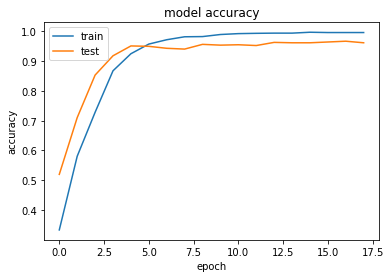

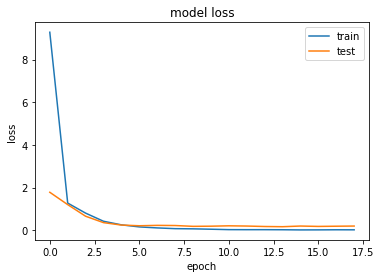

In [12]:
import matplotlib.pyplot as plt
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

In [13]:
from sklearn.metrics import classification_report

preds = model.predict(X_test)
print(preds.shape) # which means the predictions return in one-hot encoding format
preds = np.argmax(preds, axis=1)
print(preds.shape)
y_true = np.argmax(y_test, axis=1)
print(y_test.shape)
print(classification_report(y_true, preds, target_names=directories))

(756, 8)
(756,)
(756, 8)
              precision    recall  f1-score   support

         ALB       0.97      0.96      0.97       326
         BET       0.97      0.92      0.95        38
         DOL       1.00      0.96      0.98        27
         LAG       1.00      1.00      1.00        12
         NoF       0.94      0.93      0.93       100
       OTHER       0.98      0.98      0.98        57
       SHARK       1.00      1.00      1.00        33
         YFT       0.93      0.97      0.95       163

    accuracy                           0.96       756
   macro avg       0.97      0.97      0.97       756
weighted avg       0.96      0.96      0.96       756



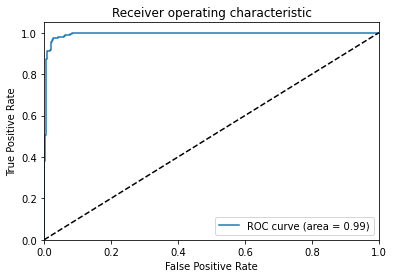

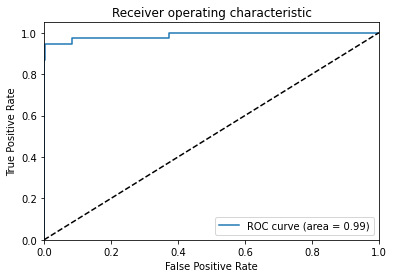

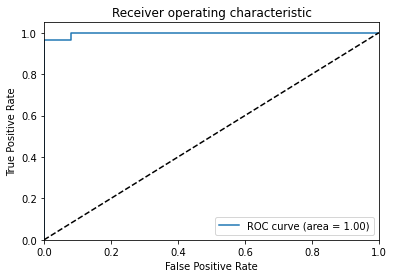

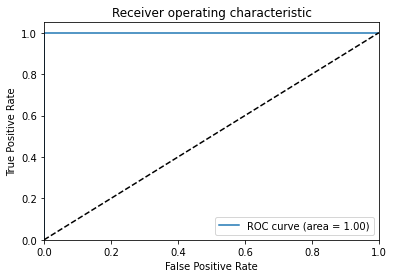

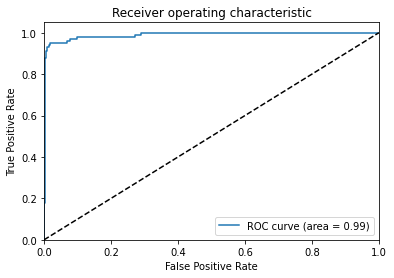

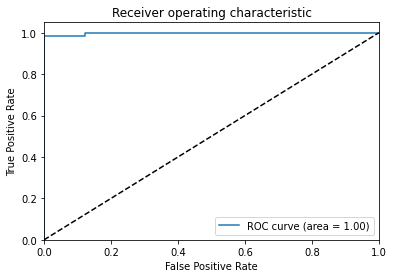

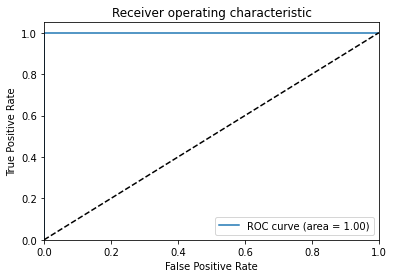

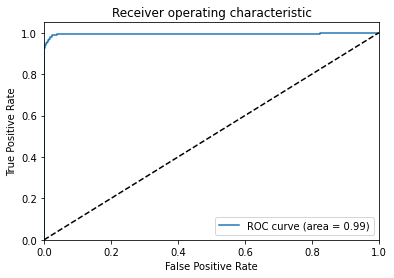

In [19]:
# Compute ROC curve and ROC area for each class
from sklearn.metrics import roc_curve, auc

y_score = model.predict(X_test) # get the prediction probabilities

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot of a ROC curve for a specific class
for i in range(num_classes):
    plt.figure()
    plt.plot(fpr[i], tpr[i], label='ROC curve (area = %0.2f)' % roc_auc[i])
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic')
    plt.legend(loc="lower right")
    plt.show()

## Transfer learning & fine-tuning

https://keras.io/api/applications/


https://keras.io/guides/transfer_learning/

In [20]:
# Step 1: import the pretrained model weights
from tensorflow.keras.applications import Xception

base_model = Xception(
    weights='imagenet',  # Load weights pre-trained on ImageNet.
    input_shape=(125, 200, 3), # your input_shape preferablly to have the same as the original pretrained model
    include_top=False)  # Do not include the ImageNet classifier at the top.

83697664/83683744 [==============================] - 7s 0us/step


In [21]:
# Step 2: Set trainable to false since you are not gonna retrain the model but will use its pretrained weights instead

base_model.trainable = False

In [24]:
# Step 3: Create your model on top
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import GlobalAveragePooling2D

inputs = Input(shape=(125, 200, 3))
x = base_model(inputs, training=False)
x1 = GlobalAveragePooling2D()(x)
outputs = Dense(num_classes, activation='softmax')(x1)
model = Model(inputs, outputs)

## Keras Tuner

https://keras.io/keras_tuner/

In [28]:
!pip install keras-tuner --upgrade

     -------------------------------------- 98.0/98.0 KB 562.6 kB/s eta 0:00:00


In [29]:
import keras_tuner as kt

In [32]:
# Step 1: build the model and compile it with the parametrs you want to optimise and search through using: 
# hp.choice('units', [8,16,32])

def build_model(hp):
    # Create the model
    model = Sequential()
    model.add(Conv2D(hp.Choice('filters', [8, 16, 32]), kernel_size=(3, 3), input_shape=(125, 200, 3), activation='relu'))
    model.add(Dropout(0.2))
    model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax')) # num_classes = 8
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model
    

In [33]:
# Step 2: use RandomSearch from keras_tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5)

In [ ]:
# Step 3: start the search
tuner.search(x_train, y_train, epochs=5, validation_data=(x_val, y_val))
best_model = tuner.get_best_models()[0]